# 🚀 AI Business Insights Pipeline

## 📌 Visão Geral

Este projeto implementa um pipeline de dados (ETL) enriquecido com Inteligência Artificial Generativa.

A proposta é transformar dados simples de empresas em **insights estratégicos**, utilizando a API do Google Gemini.

---

## 🎯 Objetivos

- Enriquecer dados com IA
- Gerar insights de negócio
- Construir dashboards analíticos
- Demonstrar práticas de Engenharia de Dados

---

## 🔄 Arquitetura

Pipeline baseado em ETL:

- **Extract** → coleta dos dados  
- **Transform** → enriquecimento com IA  
- **Load** → armazenamento dos dados  
- **Analytics** → visualização e insights  

---

## 🔐 Configuração da API (Google Gemini)

Este projeto utiliza a API do Google Gemini para gerar insights.

A autenticação é feita via:

- Google Colab (Secrets 🔑)
- ou variável de ambiente

---

### ⚠️ Importante

A API possui limites (rate limit), então utilizamos:

- Processamento em batch
- Retry com backoff exponencial

---

In [1]:
# --- INSTALAÇÃO DEPENDÊNCIA ---
!pip install -q -U google-generativeai

In [2]:
# --- IMPORTS ---
import google.generativeai as genai
import pandas as pd
import json
import time
import random
import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [3]:
# --- API KEY ---
def get_api_key():
    try:
        from google.colab import userdata
        return userdata.get('GEMINI_API_KEY')
    except:
        import os
        return os.getenv("GEMINI_API_KEY")

API_KEY = get_api_key()

if not API_KEY:
    raise ValueError("API KEY não encontrada")

genai.configure(api_key=API_KEY)

print("✅ API configurada!")

✅ API configurada!


## 🤖 Seleção Dinâmica do Modelo

- O código seleciona automaticamente um modelo compatível com geração de conteúdo.
- Isso evita falhas caso modelos sejam descontinuados.

In [4]:
def escolher_modelo():
    modelos = genai.list_models()

    for m in modelos:
        if "generateContent" in m.supported_generation_methods:
            if "flash" in m.name:
                print(f"✅ Usando modelo: {m.name}")
                return genai.GenerativeModel(m.name)

    raise Exception("Nenhum modelo encontrado")

model = escolher_modelo()

✅ Usando modelo: models/gemini-2.5-flash


## 📥 Extract (Extração de Dados)

- Nesta etapa criamos a base inicial com dados simples de empresas.
- Esses dados simulam uma fonte real (API, banco ou CSV).

In [5]:
data = {
    'empresa': ['DIO', 'TOTVS', 'Santander', 'Magazine Luiza', 'Riachuelo'],
    'website': ['dio.me', 'totvs.com', 'santander.com.br', 'magalu.com.br', 'riachuelo.com.br']
}

df = pd.DataFrame(data)

df.head()

,empresa,website
0,DIO,dio.me
1,TOTVS,totvs.com
2,Santander,santander.com.br
3,Magazine Luiza,magalu.com.br
4,Riachuelo,riachuelo.com.br


## 🔄 Transform (Enriquecimento com IA)

Nesta etapa utilizamos IA generativa para enriquecer os dados.

---

### 🧠 O que é gerado:

- Setor
- Maturidade digital
- Potencial de inovação
- Risco de mercado

---

### ⚡ Estratégia

Utilizamos processamento em batch para:

- Reduzir chamadas à API
- Evitar erro 429 (rate limit)

In [6]:
def chamar_ia(prompt):
    for tentativa in range(5):
        try:
            response = model.generate_content(prompt)
            texto = response.text.strip()
            texto = texto.replace("```json", "").replace("```", "")
            return texto

        except Exception as e:
            if "429" in str(e):
                espera = min(60, (2 ** tentativa) + random.uniform(2, 5))
                print(f"⚠️ Esperando {espera:.1f}s...")
                time.sleep(espera)
            else:
                print("Erro:", e)
                return None
    return None

In [7]:
def analisar_empresas_batch(df):
    empresas = df.to_dict(orient="records")

    prompt = f"""
    Analise as seguintes empresas:
    {empresas}

    Retorne JSON:
    [
      {{
        "empresa": "",
        "setor": "",
        "maturidade_digital": "",
        "potencial_inovacao": 0,
        "risco_mercado": 0
      }}
    ]
    """

    resposta = chamar_ia(prompt)

    if resposta:
        try:
            return pd.DataFrame(json.loads(resposta))
        except:
            print("Erro ao converter JSON")

    return pd.DataFrame()

df_ia = analisar_empresas_batch(df)

## 🧹 Limpeza e Integração dos Dados

Após o retorno da IA, os dados são:

- Convertidos de JSON
- Normalizados
- Integrados ao dataset original

Utilizamos `merge` para garantir integridade dos dados.

In [8]:
if not df_ia.empty:
    df_final = df.merge(df_ia, on="empresa", how="left")
else:
    df_final = df.copy()

df_final.head()

,empresa,website,setor,maturidade_digital,potencial_inovacao,risco_mercado
0,DIO,dio.me,Educação e Desenvolvimento Profissional em Tec...,"Muito Alta (Plataforma online, nasceu digital,...",8,6
1,TOTVS,totvs.com,"Software de Gestão Empresarial (ERP, CRM, RH),...","Muito Alta (Empresa de tecnologia, líder em so...",9,5
2,Santander,santander.com.br,"Serviços Financeiros, Bancário",Alta (Banco tradicional com investimentos mass...,7,6
3,Magazine Luiza,magalu.com.br,"Varejo Multicanal, E-commerce, Marketplace, Te...",Excepcional (Referência em transformação digit...,9,7
4,Riachuelo,riachuelo.com.br,"Varejo de Moda, E-commerce, Serviços Financeir...","Média-Alta (E-commerce consolidado, app, estra...",6,7


## 🧠 Geração de Insights

- A IA é utilizada para gerar insights estratégicos com base no dataset completo.
- Isso transforma dados em inteligência de negócio.

In [9]:
def gerar_insights(df):
    dados = df.to_dict(orient="records")

    prompt = f"""
    Com base nesses dados:
    {dados}

    Gere 5 insights estratégicos de negócio.
    """

    return chamar_ia(prompt)

insights = gerar_insights(df_final)

print(insights)

Com base nos dados fornecidos, podemos gerar os seguintes 5 insights estratégicos de negócio:

1.  **Aceleradores Digitais como Fator Crítico de Sucesso em Setores Tradicionais:**
    *   **Insight:** Empresas de setores tradicionalmente "físicos" como varejo (Magazine Luiza) e serviços financeiros (Santander) demonstram que investimentos massivos e estratégias robustas de digitalização e formação de ecossistemas (ex: Magalu Labs, Open Banking, Pix) são essenciais não apenas para a sobrevivência, mas para alcançar "maturidade digital excepcional" e alto potencial de inovação (9 e 7, respectivamente), superando concorrentes com menor maturidade e inovação (Riachuelo, com potencial 6).
    *   **Implicação Estratégica:** Priorizar e acelerar a transformação digital, mesmo em empresas estabelecidas, é um imperativo para manter a competitividade e impulsionar a inovação. Isso inclui a criação de unidades de tecnologia internas e a adoção de tecnologias emergentes.

2.  **Construção de Ecos

## 📈 Dashboard e Visualização

- Nesta etapa criamos gráficos para facilitar a análise dos dados.
- As visualizações ajudam na tomada de decisão.

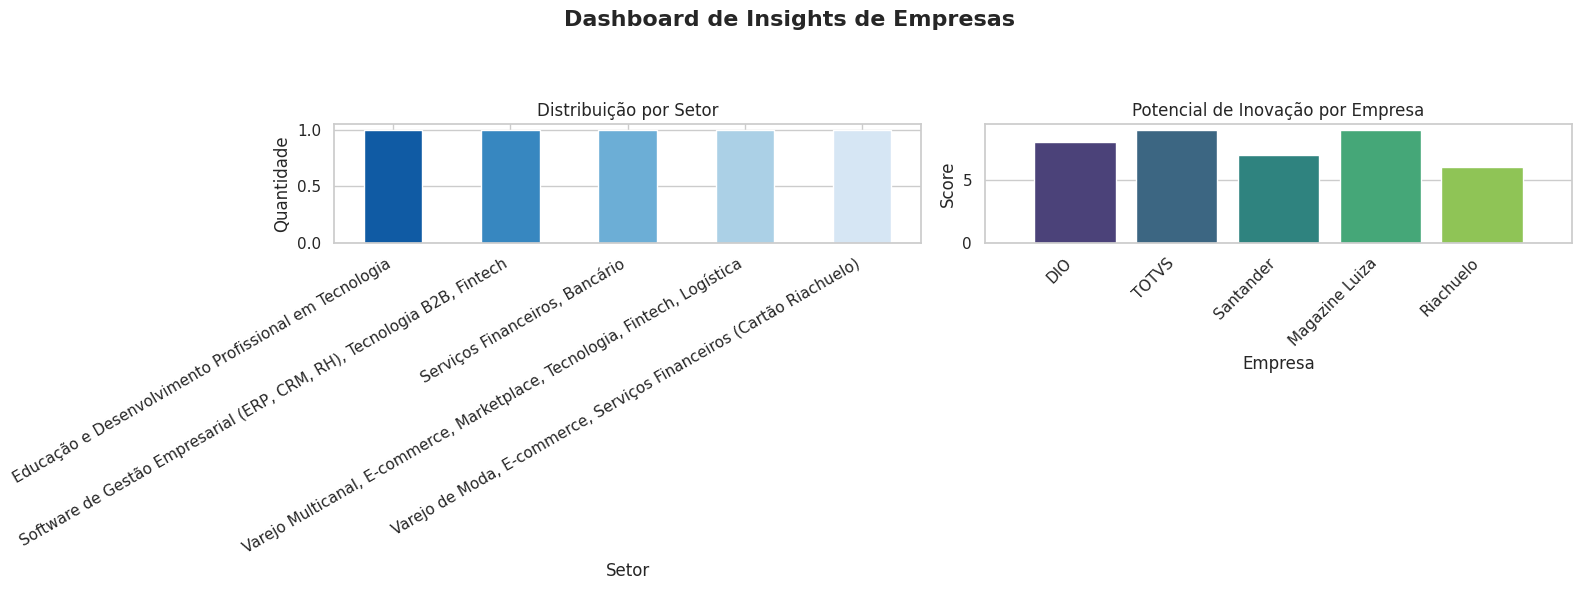

In [10]:
sns.set(style="whitegrid")

plt.figure(figsize=(16, 6))

# Título
plt.suptitle("Dashboard de Insights de Empresas", fontsize=16, fontweight='bold')

# ---------------------------
# Gráfico 1
# ---------------------------
plt.subplot(1, 2, 1)

cores_setor = sns.color_palette("Blues_r", len(df_final['setor'].value_counts()))

df_final['setor'].value_counts().plot(
    kind='bar',
    color=cores_setor
)

plt.title("Distribuição por Setor")
plt.xlabel("Setor")
plt.ylabel("Quantidade")
plt.xticks(rotation=30, ha='right')

# ---------------------------
# Gráfico 2
# ---------------------------
plt.subplot(1, 2, 2)

sns.barplot(
    x='empresa',
    y='potencial_inovacao',
    hue='empresa',
    data=df_final,
    palette="viridis",
    legend=False
)

plt.title("Potencial de Inovação por Empresa")
plt.xlabel("Empresa")
plt.ylabel("Score")
plt.xticks(rotation=45, ha='right')
plt.margins(x=0.1)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## 💾 Load (Carga de Dados)

- Nesta etapa salvamos os dados processados.
- Isso permite reutilização e integração com outras ferramentas.

In [11]:
import os

# Criar diretórios se não existirem
os.makedirs("data/processed", exist_ok=True)
os.makedirs("data/outputs", exist_ok=True)

# Salvar dados
df_final.to_csv("data/processed/dados_enriquecidos.csv", index=False)

with open("data/outputs/insights.txt", "w") as f:
    f.write(insights if insights else "")

print("✅ Pipeline finalizado!")

✅ Pipeline finalizado!
